# Лабораторная 3, вариант 2: Трансформер для перевода RU → EN

**Цель.** Обучить с нуля seq2seq-трансформер на задачу машинного перевода с русского языка на английский, используя `torch.nn.Transformer`.

**Данные.** OPUS-100 (en-ru), фильтрация по длине (`MAX_WS_LEN` / `MAX_BPE_LEN`) и эвристический фильтр шума (см. ниже).

**Подход.**
- Общий BPE-токенизатор (16K мерджей) над объединённым RU+EN корпусом.
- Стандартный Transformer encoder–decoder: `d_model=256`, 6/6 слоёв, 8 голов, FFN 1024, dropout 0.1.
- Label smoothing 0.1, Noam-расписание learning rate, AdamW ($\beta_1=0.9,\beta_2=0.98$), gradient clipping.
- Mixed precision (bfloat16) на CUDA — половина памяти активаций.
- Инференс: greedy + beam search с длиной-нормализацией.
- Метрика: corpus BLEU (`sacrebleu`) + качественные примеры.

**Структура.** Гиперпараметры → данные → токенизатор → даталоадеры → модель → обучение → графики → декодирование → BLEU → 20 примеров из теста → авторские примеры → интерактивная ячейка.

In [1]:
import os
# Должно быть установлено ДО первого обращения к CUDA — помогает с фрагментацией аллокатора.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

from pathlib import Path
import json
import math
import random
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('gpu:', torch.cuda.get_device_name(0))
    print('bf16 supported:', torch.cuda.is_bf16_supported())

device: cuda
gpu: NVIDIA GeForce RTX 4070 Laptop GPU
bf16 supported: True


/home/greg/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Гиперпараметры


In [2]:
SRC_LANG, TGT_LANG = 'ru', 'en'

# Данные
MAX_WS_LEN  = 64        # предварительный фильтр по whitespace-токенам
MAX_BPE_LEN = 96        # окончательный фильтр по BPE-токенам (после обучения токенизатора)
N_TRAIN  = 200_000
N_VAL    = 2_000
N_TEST   = 2_000

# Токенизатор
VOCAB_SIZE = 16_000

# Модель
D_MODEL    = 256
NHEAD      = 8
N_ENC      = 6
N_DEC      = 6
DIM_FF     = 1024
DROPOUT    = 0.1
NORM_FIRST = True           # pre-norm: устойчивее post-norm при длинных тренировках

# Обучение
BATCH        = 32           # уменьшено с 64 — на 8GB GPU c B=64 случались OOM на длинных батчах
EPOCHS       = 8            # после 5-й эпохи loss всё равно почти выходит на плато
WARMUP       = 8_000        # больший разогрев → ниже пик lr → меньше шанс на спайк
LABEL_SMOOTH = 0.1
CLIP         = 0.5          # ужесточили (было 1.0) после спайка при post-norm + bf16
ADAM_EPS     = 1e-8         # 1e-9 «на грани» при bf16; 1e-8 численно стабильнее
USE_AMP      = True         # bfloat16 (Ada / Ampere) — половина памяти активаций
AMP_DTYPE    = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# Декодирование
BEAM = 5

# Пути для артефактов
ROOT          = Path('.')
TOKENIZER_FP  = ROOT / 'tokenizer.json'
BEST_CKPT     = ROOT / 'best.pth'
LAST_CKPT     = ROOT / 'last.pth'
HISTORY_JSON  = ROOT / 'history.json'

print(f'BATCH={BATCH}  EPOCHS={EPOCHS}  WARMUP={WARMUP}  CLIP={CLIP}  NORM_FIRST={NORM_FIRST}  USE_AMP={USE_AMP}  AMP_DTYPE={AMP_DTYPE}')

BATCH=32  EPOCHS=8  WARMUP=8000  CLIP=0.5  NORM_FIRST=True  USE_AMP=True  AMP_DTYPE=torch.bfloat16


## Данные: OPUS-100 (ru-en)

OPUS-100 — это многосторонний параллельный корпус из 100 языковых пар. Берём подкорпус `en-ru` через `datasets`, переворачиваем направление под `ru → en`, выкидываем:

1. пустые пары,
2. **мусор:** строки с шаблоном `<<<…>>>` и пары, в которых меньше 50 % символов — буквы (в OPUS-100 много авто-выравненного шума из цифр и таблиц),
3. слишком длинные пары (> `MAX_WS_LEN` whitespace-токенов).

Затем детерминированно перемешиваем и режем по `N_TRAIN` / `N_VAL` / `N_TEST`. Финальный фильтр по BPE-длине (`MAX_BPE_LEN`) применим после обучения токенизатора.

In [3]:
from datasets import load_dataset

raw = load_dataset('Helsinki-NLP/opus-100', 'en-ru')
print({split: len(raw[split]) for split in raw})

# Фильтр шума: OPUS-100 содержит много мусорных пар вида
#   RU: <<<-9349-9348-9347-9346-9345>>>  EN: <<<402403404405406>>>
# и других строк, почти целиком состоящих из цифр/знаков.
GARBAGE_PAT = re.compile(r'<<<|>>>|^[\W\d_]+$|^\s*$')

def is_garbage(text):
    t = text.strip()
    if not t:
        return True
    if GARBAGE_PAT.search(t):
        return True
    # доля «текстовых» символов (буквы) должна быть выше порога
    letters = sum(1 for ch in t if ch.isalpha())
    if letters / max(len(t), 1) < 0.5:
        return True
    return False

def flatten(split):
    pairs = []
    for ex in split:
        en = ex['translation']['en'].strip()
        ru = ex['translation']['ru'].strip()
        if not en or not ru:
            continue
        if is_garbage(en) or is_garbage(ru):
            continue
        if len(en.split()) > MAX_WS_LEN or len(ru.split()) > MAX_WS_LEN:
            continue
        pairs.append((ru, en))
    return pairs

rng = random.Random(SEED)

train_all = flatten(raw['train'])
rng.shuffle(train_all)
train_pairs = train_all[:N_TRAIN]

val_all = flatten(raw['validation'])
rng.shuffle(val_all)
val_pairs = val_all[:N_VAL]

test_all = flatten(raw['test'])
rng.shuffle(test_all)
test_pairs = test_all[:N_TEST]

print(f'train: {len(train_pairs)} | val: {len(val_pairs)} | test: {len(test_pairs)}')
print()
for ru, en in train_pairs[:3]:
    print(f'RU: {ru}')
    print(f'EN: {en}')
    print('-' * 60)

{'test': 2000, 'train': 1000000, 'validation': 2000}
train: 200000 | val: 1853 | test: 1837

RU: - Эй, я могу войти?
EN: - Hey, uh, is it okay to come in?
------------------------------------------------------------
RU: Поздно, поздно.
EN: Too late. Too late.
------------------------------------------------------------
RU: Я не вправе обсуждать ее ни с кем бы то ни было.
EN: And far beyond what I'm able to share withomeone...
------------------------------------------------------------



## Токенизатор: общий BPE

Один Byte-Pair-Encoding-токенизатор обучается на объединённом потоке русского и английского текста из обучающей выборки. Это даёт компактную таблицу эмбеддингов и позволяет модели делить подстроки между языками (числа, имена собственные, заимствования). Спецтокены:

- `[PAD]` — паддинг,
- `[UNK]` — неизвестный токен,
- `[BOS]` — начало последовательности декодера,
- `[EOS]` — конец последовательности.

Если файл `tokenizer.json` уже существует — токенизатор подгружается из него.


In [4]:

from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

SPECIALS = ['[PAD]', '[UNK]', '[BOS]', '[EOS]']

if TOKENIZER_FP.exists():
    tok = Tokenizer.from_file(str(TOKENIZER_FP))
    print(f'Загружен токенизатор из {TOKENIZER_FP}')
else:
    tok = Tokenizer(models.BPE(unk_token='[UNK]'))
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()

    trainer = trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE,
        special_tokens=SPECIALS,
        min_frequency=2,
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    )

    def iter_train():
        for ru, en in train_pairs:
            yield ru
            yield en

    tok.train_from_iterator(iter_train(), trainer=trainer, length=2 * len(train_pairs))
    tok.save(str(TOKENIZER_FP))
    print(f'Сохранён токенизатор -> {TOKENIZER_FP}')

PAD_ID = tok.token_to_id('[PAD]')
UNK_ID = tok.token_to_id('[UNK]')
BOS_ID = tok.token_to_id('[BOS]')
EOS_ID = tok.token_to_id('[EOS]')
VOCAB  = tok.get_vocab_size()
print(f'vocab={VOCAB} | PAD={PAD_ID} UNK={UNK_ID} BOS={BOS_ID} EOS={EOS_ID}')

# Проверка кодирования/декодирования
demo = 'Привет, мир! 123'
ids = tok.encode(demo).ids
print(f'{demo!r} -> {ids[:15]}{"..." if len(ids) > 15 else ""}')
print('decode:', tok.decode(ids))


Загружен токенизатор из tokenizer.json
vocab=16000 | PAD=0 UNK=1 BOS=2 EOS=3
'Привет, мир! 123' -> [3943, 15, 1370, 4, 1354, 22]
decode: Привет, мир! 123



## Dataset и DataLoader

Каждый пример возвращает пару тензоров `(src_ids, tgt_ids)`:

- источник: `[t1 … tn EOS]`,
- цель: `[BOS t1 … tn EOS]`.

В `collate_fn` пэддим обе стороны до длины максимального примера в батче, отделяем target-input (`[BOS … tN]`) от target-output (`[t1 … EOS]`) и строим pad-маски (`True` = паддинг).


In [5]:
def encode_src(text):
    ids = tok.encode(text).ids
    return ids + [EOS_ID]

def encode_tgt(text):
    ids = tok.encode(text).ids
    return [BOS_ID] + ids + [EOS_ID]


def filter_by_bpe(pairs, max_len=MAX_BPE_LEN):
    """Отбрасываем пары, у которых после BPE длина источника или цели превышает max_len.
       Это окончательный фильтр — он напрямую ограничивает форму батчей и потребление памяти."""
    kept = []
    for ru, en in tqdm(pairs, desc='filter bpe'):
        if len(encode_src(ru)) > max_len:
            continue
        if len(encode_tgt(en)) > max_len:
            continue
        kept.append((ru, en))
    return kept

train_pairs = filter_by_bpe(train_pairs)
val_pairs   = filter_by_bpe(val_pairs)
test_pairs  = filter_by_bpe(test_pairs)
print(f'после BPE-фильтра: train={len(train_pairs)} | val={len(val_pairs)} | test={len(test_pairs)}')


class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ru, en = self.pairs[idx]
        return (torch.tensor(encode_src(ru), dtype=torch.long),
                torch.tensor(encode_tgt(en), dtype=torch.long))


def collate(batch):
    srcs, tgts = zip(*batch)
    src = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_ID)
    tgt = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_ID)
    tgt_in  = tgt[:, :-1]
    tgt_out = tgt[:, 1:]
    src_pad_mask = (src == PAD_ID)
    tgt_pad_mask = (tgt_in == PAD_ID)
    return src, tgt_in, tgt_out, src_pad_mask, tgt_pad_mask


train_ds = TranslationDataset(train_pairs)
val_ds   = TranslationDataset(val_pairs)
test_ds  = TranslationDataset(test_pairs)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True)

sample = next(iter(train_loader))
print('shapes:', [tuple(t.shape) for t in sample[:3]])
print('src[0]:', sample[0][0][:12].tolist(), '...')
print('tgt[0]:', sample[1][0][:12].tolist(), '...')

filter bpe: 100%|██████████| 1837/1837 [00:00<00:00, 14659.79it/s]

после BPE-фильтра: train=198882 | val=1837 | test=1815


shapes: [(32, 51), (32, 85), (32, 85)]
src[0]: [515, 362, 385, 8584, 1543, 2246, 3623, 374, 10415, 3893, 7619, 447] ...
tgt[0]: [2, 452, 2599, 9051, 315, 286, 10766, 3016, 551, 331, 1873, 3961] ...



## Модель: `torch.nn.Transformer`

Стандартная архитектура из *«Attention Is All You Need»*. Обёртка `Seq2SeqTransformer` добавляет:

- общую таблицу эмбеддингов размера `VOCAB × d_model` (один токенизатор → одна таблица);
- синусоидальное позиционное кодирование (фиксированные веса);
- линейный «выходной слой» `d_model → VOCAB` поверх декодера.

Для предотвращения «подсматривания» в будущее используем стандартную причинно-треугольную маску `generate_square_subsequent_mask`. Pad-маски передаются отдельно (`*_key_padding_mask`).

Все тензоры в формате `batch_first=True`, форма `(B, T, *)`.


In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


def generate_square_subsequent_mask(sz, device):
    # bool-маска (True = запрещённая позиция). Согласована по типу с key_padding_mask,
    # чтобы избежать предупреждения «mismatched key_padding_mask and attn_mask».
    return torch.triu(torch.ones(sz, sz, dtype=torch.bool, device=device), diagonal=1)


class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab, d_model, nhead, n_enc, n_dec, dim_ff, dropout, pad_id, norm_first=True):
        super().__init__()
        self.d_model = d_model
        self.pad_id  = pad_id
        self.tok_emb = nn.Embedding(vocab, d_model, padding_idx=pad_id)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=n_enc, num_decoder_layers=n_dec,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True, norm_first=norm_first,
        )
        self.proj = nn.Linear(d_model, vocab)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def embed(self, x):
        return self.pos_enc(self.tok_emb(x) * math.sqrt(self.d_model))

    def encode(self, src, src_pad_mask):
        return self.transformer.encoder(self.embed(src), src_key_padding_mask=src_pad_mask)

    def decode(self, tgt, memory, tgt_mask, tgt_pad_mask, src_pad_mask):
        return self.transformer.decoder(
            self.embed(tgt), memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )

    def forward(self, src, tgt_in, src_pad_mask, tgt_pad_mask):
        T = tgt_in.size(1)
        tgt_mask = generate_square_subsequent_mask(T, src.device)
        memory = self.encode(src, src_pad_mask)
        dec = self.decode(tgt_in, memory, tgt_mask, tgt_pad_mask, src_pad_mask)
        return self.proj(dec)


model = Seq2SeqTransformer(VOCAB, D_MODEL, NHEAD, N_ENC, N_DEC, DIM_FF, DROPOUT, PAD_ID,
                           norm_first=NORM_FIRST).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'параметров: {n_params/1e6:.2f}M  (norm_first={NORM_FIRST})')

# Санити-чек: forward на случайном батче
with torch.no_grad():
    _src = torch.randint(4, VOCAB, (2, 10), device=device)
    _tgt = torch.randint(4, VOCAB, (2, 8),  device=device)
    _out = model(_src, _tgt,
                 src_pad_mask=torch.zeros_like(_src, dtype=torch.bool),
                 tgt_pad_mask=torch.zeros_like(_tgt, dtype=torch.bool))
    assert _out.shape == (2, 8, VOCAB), _out.shape
print('forward OK, shape:', tuple(_out.shape))

параметров: 19.27M  (norm_first=True)


/home/greg/miniconda3/envs/ml/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


forward OK, shape: (2, 8, 16000)



## Обучение

- **Loss:** `CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)` — паддинг исключаем из loss; label smoothing уменьшает переуверенность.
- **Optimizer:** `AdamW` с $\beta_1=0.9$, $\beta_2=0.98$, $\varepsilon=10^{-9}$.
- **LR-расписание:** Noam,
$\operatorname{lr}(t) = d_\text{model}^{-0.5}\,\min\!\bigl(t^{-0.5},\; t\cdot\text{warmup}^{-1.5}\bigr)$
— линейный разогрев `WARMUP` шагов, далее обратный корень.
- **Grad clip:** норма 1.0.
- **Чекпоинт:** `best.pth` обновляется при улучшении val-loss; `last.pth` сохраняется после каждой эпохи; история — в `history.json`.

Если `best.pth` и `history.json` уже существуют — обучение пропускается, веса подгружаются из чекпоинта (чтобы не тренировать заново при повторном открытии ноутбука).


In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTH)
optimizer = optim.AdamW(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=ADAM_EPS)
# lr=1.0 в оптимизаторе нейтрален — фактическое значение задаёт LambdaLR через множитель Noam.

def noam_lr(step):
    step = max(step, 1)
    return (D_MODEL ** -0.5) * min(step ** -0.5, step * (WARMUP ** -1.5))

scheduler = LambdaLR(optimizer, lr_lambda=noam_lr)

# Mixed precision: bfloat16 на Ada/Ampere (без GradScaler), иначе fp16 (со скалером).
scaler = torch.amp.GradScaler('cuda', enabled=(USE_AMP and AMP_DTYPE == torch.float16))


def train_epoch(epoch):
    model.train()
    total, n = 0.0, 0
    pbar = tqdm(train_loader, desc=f'эпоха {epoch} train')
    for src, tgt_in, tgt_out, src_pm, tgt_pm in pbar:
        src, tgt_in, tgt_out = src.to(device, non_blocking=True), tgt_in.to(device, non_blocking=True), tgt_out.to(device, non_blocking=True)
        src_pm, tgt_pm = src_pm.to(device, non_blocking=True), tgt_pm.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(src, tgt_in, src_pm, tgt_pm)
            loss = criterion(logits.reshape(-1, VOCAB), tgt_out.reshape(-1))

        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            optimizer.step()
        scheduler.step()

        bs = src.size(0)
        total += loss.item() * bs; n += bs
        pbar.set_postfix(loss=f'{total/n:.4f}', lr=f'{scheduler.get_last_lr()[0]:.2e}')
    return total / n


@torch.no_grad()
def evaluate(loader, name='val'):
    model.eval()
    total, n = 0.0, 0
    for src, tgt_in, tgt_out, src_pm, tgt_pm in tqdm(loader, desc=name):
        src, tgt_in, tgt_out = src.to(device, non_blocking=True), tgt_in.to(device, non_blocking=True), tgt_out.to(device, non_blocking=True)
        src_pm, tgt_pm = src_pm.to(device, non_blocking=True), tgt_pm.to(device, non_blocking=True)
        with torch.amp.autocast(device_type='cuda', dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(src, tgt_in, src_pm, tgt_pm)
            loss = criterion(logits.reshape(-1, VOCAB), tgt_out.reshape(-1))
        bs = src.size(0)
        total += loss.item() * bs; n += bs
    return total / n


if BEST_CKPT.exists() and HISTORY_JSON.exists():
    print(f'Найден чекпоинт {BEST_CKPT} — обучение пропущено.')
    print('Удалите best.pth и history.json для повторного запуска.')
    model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))
else:
    history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')
    for epoch in range(1, EPOCHS + 1):
        tr = train_epoch(epoch)
        torch.cuda.empty_cache()
        vl = evaluate(val_loader, name=f'эпоха {epoch} val')
        torch.cuda.empty_cache()
        history['train_loss'].append(tr)
        history['val_loss'].append(vl)
        print(f'эпоха {epoch}: train={tr:.4f} | val={vl:.4f}')
        torch.save(model.state_dict(), LAST_CKPT)
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), BEST_CKPT)
            print(f'  → новый лучший val: {best_val:.4f}, сохранено в {BEST_CKPT}')
        with open(HISTORY_JSON, 'w') as f:
            json.dump(history, f, indent=2)
    model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))
    print('Обучение завершено, загружен лучший чекпоинт.')

эпоха 1 val: 100%|██████████| 58/58 [00:01<00:00, 52.33it/s]


эпоха 1: train=6.1341 | val=5.3661
  → новый лучший val: 5.3661, сохранено в best.pth


эпоха 2 val: 100%|██████████| 58/58 [00:01<00:00, 53.12it/s]


эпоха 2: train=4.8467 | val=4.5811
  → новый лучший val: 4.5811, сохранено в best.pth


эпоха 3 val: 100%|██████████| 58/58 [00:01<00:00, 53.17it/s]


...

эпоха 6: train=3.7098 | val=3.8286
  → новый лучший val: 3.8286, сохранено в best.pth


эпоха 7 val: 100%|██████████| 58/58 [00:01<00:00, 52.80it/s]


эпоха 7: train=3.6188 | val=3.7693
  → новый лучший val: 3.7693, сохранено в best.pth


эпоха 8 val: 100%|██████████| 58/58 [00:01<00:00, 52.62it/s]


эпоха 8: train=3.5428 | val=3.7338
  → новый лучший val: 3.7338, сохранено в best.pth
Обучение завершено, загружен лучший чекпоинт.



## Кривые потерь


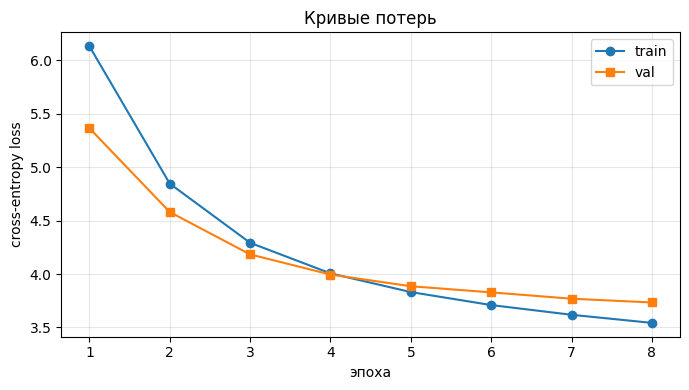

In [8]:

with open(HISTORY_JSON) as f:
    history = json.load(f)

epochs = list(range(1, len(history['train_loss']) + 1))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, history['train_loss'], marker='o', label='train')
ax.plot(epochs, history['val_loss'],   marker='s', label='val')
ax.set_xlabel('эпоха')
ax.set_ylabel('cross-entropy loss')
ax.set_title('Кривые потерь')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()



## Декодирование

Реализуем две стратегии:

- **Greedy** — на каждом шаге берём `argmax` от логитов. Быстро, но локально оптимально.
- **Beam search** — параллельно ведём $K$ гипотез, на каждом шаге расширяем каждую top-$K$ продолжениями и оставляем $K$ лучших по суммарной log-вероятности. Финальный ранг — по длине-нормализованному скору с штрафом $(\,(5+L)/6\,)^{\alpha}$, $\alpha=0.6$ (Wu et al., 2016, GNMT).


In [9]:

@torch.no_grad()
def greedy_decode(model, src_text, max_len=80):
    model.eval()
    src_ids = torch.tensor([encode_src(src_text)], device=device)
    src_pm  = (src_ids == PAD_ID)
    memory  = model.encode(src_ids, src_pm)

    ys = torch.tensor([[BOS_ID]], device=device)
    for _ in range(max_len):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device)
        out = model.decode(ys, memory, tgt_mask,
                           tgt_pad_mask=(ys == PAD_ID),
                           src_pad_mask=src_pm)
        logits = model.proj(out[:, -1])
        nxt = int(logits.argmax(-1).item())
        ys = torch.cat([ys, torch.tensor([[nxt]], device=device)], dim=1)
        if nxt == EOS_ID:
            break

    ids = ys[0].tolist()[1:]                 # отрезаем BOS
    if ids and ids[-1] == EOS_ID:
        ids = ids[:-1]                       # и EOS
    return tok.decode(ids)


In [10]:

@torch.no_grad()
def beam_search_decode(model, src_text, beam_size=BEAM, max_len=80, length_penalty=0.6):
    model.eval()
    src_ids = torch.tensor([encode_src(src_text)], device=device)
    src_pm  = (src_ids == PAD_ID)
    memory  = model.encode(src_ids, src_pm)

    def norm(tokens, score):
        L = max(len(tokens) - 1, 1)          # без BOS
        return score / (((5 + L) / 6) ** length_penalty)

    # Луч: [tokens, log_prob_sum]
    beams = [[[BOS_ID], 0.0]]
    finished = []

    for _ in range(max_len):
        if not beams:
            break

        ys = torch.tensor([b[0] for b in beams], device=device)
        B  = ys.size(0)
        mem_b   = memory.expand(B, -1, -1)
        src_pm_b = src_pm.expand(B, -1)
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device)
        out = model.decode(ys, mem_b, tgt_mask,
                           tgt_pad_mask=(ys == PAD_ID),
                           src_pad_mask=src_pm_b)
        log_probs = torch.log_softmax(model.proj(out[:, -1]), dim=-1)
        topk_lp, topk_idx = log_probs.topk(beam_size, dim=-1)

        cands = []
        for i, (tokens, score) in enumerate(beams):
            for k in range(beam_size):
                nxt = int(topk_idx[i, k].item())
                nlp = float(topk_lp[i, k].item())
                cands.append((tokens + [nxt], score + nlp))

        cands.sort(key=lambda c: norm(c[0], c[1]), reverse=True)

        next_beams = []
        for tokens, score in cands:
            if tokens[-1] == EOS_ID:
                finished.append((tokens, score))
            else:
                next_beams.append([tokens, score])
            if len(next_beams) == beam_size:
                break
        beams = next_beams

        if len(finished) >= beam_size:
            break

    pool = finished + [(b[0], b[1]) for b in beams]
    pool.sort(key=lambda c: norm(c[0], c[1]), reverse=True)

    ids = pool[0][0][1:]                     # без BOS
    if ids and ids[-1] == EOS_ID:
        ids = ids[:-1]
    return tok.decode(ids)



## Метрика: corpus BLEU

Считаем BLEU через `sacrebleu` на первых `N_BLEU` парах из тестовой выборки — отдельно для greedy и beam search. Полный обход теста beam-поиском медленный, поэтому ограничиваемся 500 примерами для отчёта (значение `N_BLEU` ниже можно поднять).


In [11]:

import sacrebleu

def translate_corpus(pairs, decoder_fn, desc):
    hyps, refs = [], []
    for ru, en in tqdm(pairs, desc=desc):
        hyps.append(decoder_fn(ru))
        refs.append(en)
    return hyps, refs

N_BLEU = min(500, len(test_pairs))
bleu_pairs = test_pairs[:N_BLEU]

g_hyps, refs = translate_corpus(bleu_pairs, lambda t: greedy_decode(model, t), desc='greedy')
bleu_g = sacrebleu.corpus_bleu(g_hyps, [refs])
print(f'GREEDY BLEU @ {N_BLEU}: {bleu_g.score:.2f}')

b_hyps, _ = translate_corpus(bleu_pairs, lambda t: beam_search_decode(model, t, BEAM), desc='beam')
bleu_b = sacrebleu.corpus_bleu(b_hyps, [refs])
print(f'BEAM-{BEAM} BLEU @ {N_BLEU}: {bleu_b.score:.2f}')


greedy: 100%|██████████| 500/500 [00:54<00:00,  9.24it/s]


GREEDY BLEU @ 500: 20.27


beam: 100%|██████████| 500/500 [01:20<00:00,  6.20it/s]

BEAM-5 BLEU @ 500: 21.86



## 20 примеров из тестовой выборки

Подбираем разнообразные по длине пары: 5 коротких (≤6 слов), 10 средних (7–20 слов) и 5 длинных (>20 слов). Для каждой выводим эталон (REF) и предсказания greedy/beam.


In [12]:

def pick_diverse(pairs, n_short=5, n_med=10, n_long=5, seed=SEED):
    short, med, long = [], [], []
    for ru, en in pairs:
        w = len(ru.split())
        if w <= 6:
            short.append((ru, en))
        elif w <= 20:
            med.append((ru, en))
        else:
            long.append((ru, en))
    r = random.Random(seed)
    r.shuffle(short); r.shuffle(med); r.shuffle(long)
    return short[:n_short] + med[:n_med] + long[:n_long]

samples = pick_diverse(test_pairs)
print(f'Подобрано {len(samples)} примеров')
print('=' * 80)
for i, (ru, en) in enumerate(samples, 1):
    g = greedy_decode(model, ru)
    b = beam_search_decode(model, ru, BEAM)
    print(f'[{i:02d}] RU:     {ru}')
    print(f'     REF:    {en}')
    print(f'     GREEDY: {g}')
    print(f'     BEAM:   {b}')
    print('-' * 80)


Подобрано 20 примеров
[01] RU:     Потянемся к небу.
     REF:    Reach out to the sky.
     GREEDY: We're gonna get to the sky.
     BEAM:   We'll get to the sky.
--------------------------------------------------------------------------------
[02] RU:     Маргаритка сбегает по частям.
     REF:    Pâquerette is escaping pieces by pieces.
     GREEDY: Marcotics are running on the private.
     BEAM:   The Margaret is running on the public.
--------------------------------------------------------------------------------
[03] RU:     Его корабль пропал.
     REF:    His ship, it's gone.
     GREEDY: His ship's gone.
     BEAM:   His ship's gone.
--------------------------------------------------------------------------------
[04] RU:     Я выкуплю Summer Breeze.
     REF:    - Definitely. So all I need is money.
     GREEDY: I'll take the epidemic Breeze.
     BEAM:   I'll get the Camer Breeze.
--------------------------------------------------------------------------------
[05] RU:    


## Авторские примеры

Сочинённые предложения, покрывающие разные жанры/феномены: формальное приветствие, разговорная речь, отрицание, вопрос, имена собственные, числа/даты, технический термин, идиома, длинное составное предложение, многозначное слово.


In [13]:

authored = [
    'Доброе утро, рад вас видеть.',
    'Слушай, давай уже пойдём, я устал.',
    'Не лезь не в своё дело.',
    'Иван Петрович родился в Москве в 1985 году.',
    'Цена выросла с 1200 до 1500 рублей за килограмм.',
    'Я никогда не говорил, что не люблю этот фильм.',
    'Сколько ещё ждать до отправления поезда?',
    'Хотя погода была плохой, мы всё равно решили пойти в поход и провели прекрасный день у озера.',
    'Этот нейросетевой алгоритм использует механизм внимания для перевода предложений.',
    'Он быстро бросил ключ в замок и открыл дверь.',
]

for i, ru in enumerate(authored, 1):
    b = beam_search_decode(model, ru, BEAM)
    print(f'[{i:02d}] RU: {ru}')
    print(f'     EN: {b}')
    print('-' * 80)


[01] RU: Доброе утро, рад вас видеть.
     EN: Good morning, pleasure to see you.
--------------------------------------------------------------------------------
[02] RU: Слушай, давай уже пойдём, я устал.
     EN: Look, let's go, I'm tired.
--------------------------------------------------------------------------------
[03] RU: Не лезь не в своё дело.
     EN: Don't lie to your case.
--------------------------------------------------------------------------------
[04] RU: Иван Петрович родился в Москве в 1985 году.
     EN: Ivan Petroov was born in Moscow in 1985.
--------------------------------------------------------------------------------
[05] RU: Цена выросла с 1200 до 1500 рублей за килограмм.
     EN: The price grew up 1200 to 1500 rubles in the program.
--------------------------------------------------------------------------------
[06] RU: Я никогда не говорил, что не люблю этот фильм.
     EN: I never said that I don't like this movie.
-----------------------------------


## Интерактивный перевод

Измените текст переменной `text` ниже и перезапустите ячейку, чтобы получить перевод. Эту ячейку удобно показывать проверяющим — они дают свой пример, мы заменяем строку и жмём `Shift+Enter`.


In [14]:

text = 'Сегодня хороший день для машинного перевода.'
print('RU:', text)
print('EN:', beam_search_decode(model, text, BEAM))


RU: Сегодня хороший день для машинного перевода.
EN: Today a good day for the machine translation.
